In [26]:

import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy
import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats
import plot_settings
import importlib
import multi_exp_log
sys.path.append('..')

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(multi_exp_log)

import_reload()

# Importing data

In [27]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [28]:


def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    # cols = u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
    #df.columns = ['u_par','C','t','V','I','F','u','Ue','eta','trajectory','dV','dF','soc']
    # Sort by time within each batch
    return df


path = f'2_merged_data'

data = read_data(path)
display(data.head())


,u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,-0.085164,0,-0.027881,-0.000470,0.999389
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,-0.111187,0,-0.016738,-0.000471,0.998778
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,-0.126065,0,-0.011734,-0.000471,0.998167
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,-0.135938,0,-0.006706,-0.000471,0.997556
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,-0.140783,0,-0.005763,-0.000471,0.996944


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

## The sampled terrain

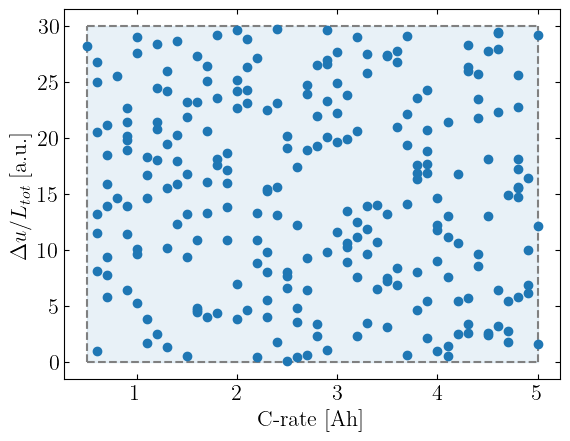

In [29]:
u_C_pairs = data.loc[data['t'] == 0, ['u_par', 'C']]
plt.xlabel('C-rate [Ah]')
plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
plt.vlines(0.5,0,30, color='gray', linestyle='--')
plt.vlines(5,0,30, color='gray', linestyle='--')
plt.hlines(0,0.5,5, color='gray', linestyle='--')
plt.hlines(30,0.5,5, color='gray', linestyle='--')
plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o')

# Plotting data

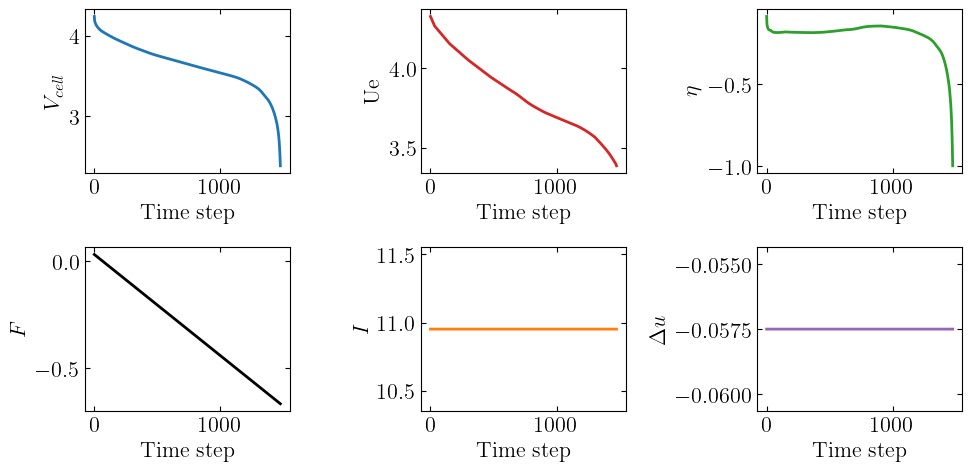

In [30]:

plot_idx = data['trajectory'] == 0
f, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0,0].plot(data['V'][plot_idx], '-', color = colors[0], lw = 2)
ax[0,0].set_xlabel('Time step')
ax[0,0].set_ylabel('$V_{cell}$')
ax[0,1].plot(data['Ue'][plot_idx], '-', color = colors[1], lw = 2)
ax[0,1].set_xlabel('Time step')
ax[0,1].set_ylabel('Ue')
ax[0,2].plot(data['eta'][plot_idx], '-', color = colors[2], lw = 2)
ax[0,2].set_xlabel('Time step')
ax[0,2].set_ylabel(r'$\eta$')
ax[1,0].plot(data['F'][plot_idx], lw = 2,color = colors[3])
ax[1,0].set_xlabel('Time step')
ax[1,0].set_ylabel(r'$F$')
ax[1,1].plot(data['I'][plot_idx], lw = 2,color = colors[4])
ax[1,1].set_xlabel('Time step')
ax[1,1].set_ylabel(r'$I$')
ax[1,2].plot(data['u'][plot_idx], lw = 2,color = colors[5])
ax[1,2].set_xlabel('Time step')
ax[1,2].set_ylabel(r'$\Delta u$')

plt.tight_layout()
plt.show()

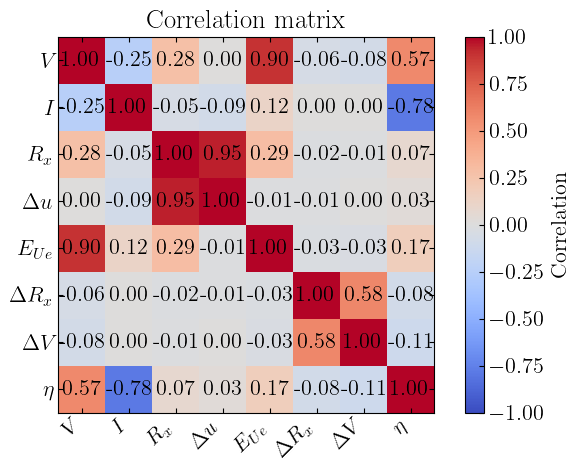

In [31]:
# Correlation matrix for current signals in this batch

X = data[['V','I','F','u_par','Ue','dF','dV','eta']].values
feature_names = ['$V$','$I$','$R_x$',r'$\Delta u$','$E_{Ue}$',r'$\Delta R_x$',r'$\Delta V$',r'$\eta$']
with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)


fig, ax_corr = plt.subplots(figsize=(7, 5))
im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(feature_names)))
ax_corr.set_yticks(np.arange(len(feature_names)))
ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
ax_corr.set_yticklabels(feature_names)
ax_corr.set_title("Correlation matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax_corr, label="Correlation")
plt.tight_layout()
plt.show()

53.164 GN/mm


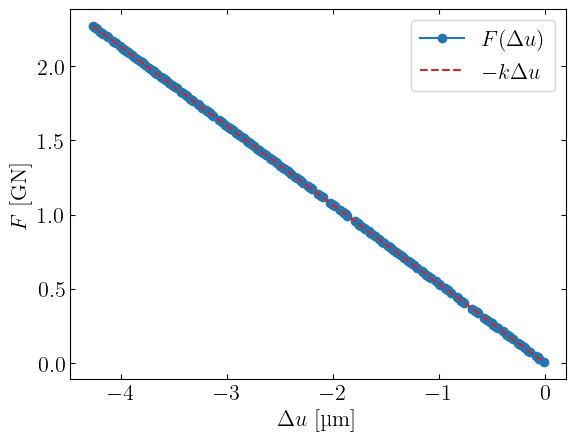

In [32]:
traj = 0
#plt.plot(data['u'][data['trajectory'] == traj], data['F'][data['trajectory'] == traj], lw = 2, color = colors[0])
groups = data.groupby('u')['F']


first_F = data.groupby('u')['F'].first()
k = abs(first_F / (data.groupby('u')['u'].first()))
plt.plot(data.groupby('u')['u'].first(), first_F, 'o-', color = colors[0], label = r'$F(\Delta u)$')
plt.plot(data.groupby('u')['u'].first(), -k * data.groupby('u')['u'].first(), '--', color = colors[1], label = r'$-k\Delta u$')
plt.xlabel(r'$\Delta u$ [µm]')
plt.ylabel(r'$F$ [GN]')
plt.legend()
print(f'{100 * k.values[0]:.3f} GN/mm')


Text(0, 0.5, '$F$ [MN]')

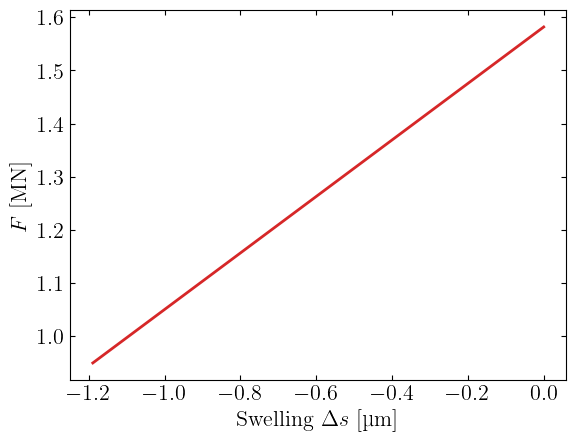

In [33]:
traj = 1

ds = data['F'][data['trajectory'] == traj] / k.values[0] + data['u'][data['trajectory'] == traj] 

plt.plot(ds,data['F'][data['trajectory'] == traj], lw = 2, color = colors[1])
plt.xlabel(r'Swelling $\Delta s$ [µm]')
plt.ylabel(r'$F$ [MN]')

In [34]:
def GP_process(traj_max = False):
    sig = 1
    l = 0.1
    alpha = [l, sig]
    traj_max = data['trajectory'][np.argmin(data['soc'].values)]
    x_gp = data['soc'][data['trajectory'] == traj_max].values
    y_gp = data['Ue'][data['trajectory'] == traj_max].values
    kernel_GP = gp.kernels.RBF(length_scale=alpha[0]) * gp.kernels.ConstantKernel(constant_value=alpha[1])
    gp_model = gp.GaussianProcessRegressor(kernel=kernel_GP,optimizer=None,normalize_y=False)

    gp_model.fit(x_gp.reshape(-1,1), y_gp.reshape(-1,1))
    if traj_max:
        return gp_model, traj_max
    else:
        return gp_model
gp_fit,tr_max = GP_process(traj_max = True)

# print tr_max and the minimum soc value
print(f"Trajectory with minimum SOC: {tr_max}")
print(f"Minimum SOC value: {np.min(data['soc'].values):.4f}")

def soc_to_Ue(soc, gp_fit = gp_fit):
    return gp_fit.predict(soc.reshape(-1,1))

Trajectory with minimum SOC: 136
Minimum SOC value: 0.0210


GP sampling took 0.4639 seconds for 7049 points => 0.066 ms/point
MSE: 5.271350e-07


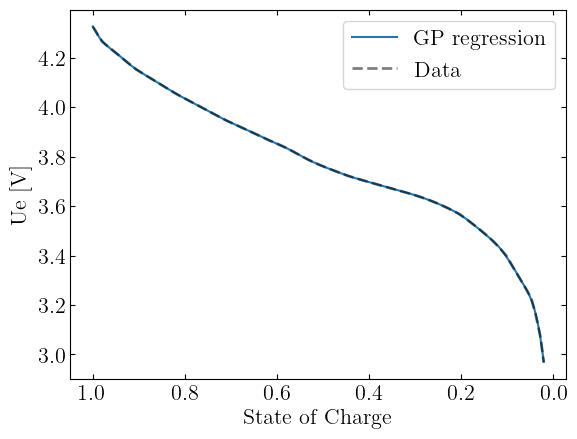

In [35]:
start = time.perf_counter()
Ue_sample = soc_to_Ue(data['soc'][data['trajectory'] == tr_max].values)
end = time.perf_counter()
print(f"GP sampling took {end - start:.4f} seconds for {len(data['soc'][data['trajectory'] == tr_max].values)} points => {len(data['soc'][data['trajectory'] == tr_max].values)**(-1) *1000* (end - start):.3f} ms/point")
plt.plot((data['soc'][data['trajectory'] == tr_max].values), Ue_sample, color = colors[0], label = 'GP regression')
plt.plot(data['soc'][data['trajectory'] == tr_max].values, data['Ue'][data['trajectory'] == tr_max].values, lw = 2, color = 'black', label = 'Data',ls = '--', alpha = 0.5)
plt.xlabel('State of Charge')
plt.gca().invert_xaxis()
plt.ylabel('Ue [V]')
plt.legend()
print(f'MSE: {np.mean((Ue_sample - data["Ue"][data["trajectory"] == tr_max].values)**2):.6e}')

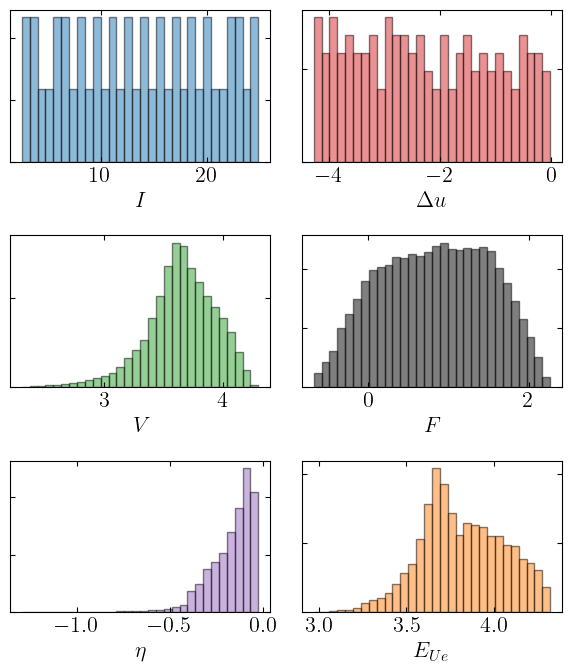

In [38]:
f, ax = plt.subplots(3,2,figsize=(6, 7))
ax[0,0].hist(np.unique(data['I']), bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(np.unique(data['u']) , bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(np.unique(data['F']), bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['Ue'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist((data['eta']), bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$')
ax[0,1].set_xlabel(r'$\Delta u$')
ax[1,0].set_xlabel('$V$')
ax[1,1].set_xlabel('$F$')
ax[2,1].set_xlabel('$E_{Ue}$')
ax[2,0].set_xlabel(r'$\eta$')
#ax[2,0].set_xlabel('$E_{Ue}$')
#ax[2,1].set_xlabel('$d$')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

In [39]:
N_trajs = len(data['trajectory'].unique())


X = data[['u', 'trajectory']].values
y = data[['F','trajectory']].values

In [40]:
x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

split = (data['trajectory']<=int(N_trajs *0.8)).sum()

def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test = _split_flat(x_tensor); y_train, y_test = _split_flat(y_tensor)

print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')

print(f'\nX shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')


#df_train = data[data['trajectory'] <= int(N_trajs * 0.8)]
#df_test = data[data['trajectory'] > int(N_trajs * 0.8)]

#train_loader_flat = DataLoader(TensorDataset(x_train, y_train), shuffle=False)

Number of trajectories in train: 198 out of 248

X shape torch.Size([415557, 2])	y shape torch.Size([415557, 2])
X-train shape: torch.Size([334590, 2])	y-train shape: torch.Size([334590, 2])
X-test shape: torch.Size([80967, 2])	y-test shape: torch.Size([80967, 2])


In [ ]:
''' Mk 1 '''
import torch.nn.functional as TF

def ECM_box(soc, I, R0):
    Ue = soc_to_Ue(soc)
    return Ue - I * R0

def Mech_box(u,Fs , k = k.values[0]):
    return -k * u + Fs

def force_func(soc):
    return 1 - np.exp(250*(soc - 1))



class Net(nn.Module):
    def __init__(self, input_size=1, hidden_size=256): 
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)   # output size is 2 for (V_cell, F)
        )

    def forward(self, x):
        if False:
            R0_raw, Fs_raw = self.net(x)[0], self.net(x)[1]
            R0 = TF.softplus(R0_raw)  # Ensure R0 is non-negative
            Fs = Fs_raw#-TF.softplus(-Fs_raw)  # Ensure Fs is non-positive
            return R0, Fs
        if True:
            return self.net(x)

model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)  

In [56]:
try: 
    print(summary(model, input_data=x_train[:2]))
except Exception as e:
    print(f"Error in model summary: {e}")

Error in model summary: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: []


In [59]:
# def next_step(x, Ue, I, k, u):
#     R0_dot, F_dot = model(x)
#     R0 = R0_dot * dt + x[:,0]
#     F  = F_dot  * dt + x[:,1] 

#     Vt = ECM_box(Ue,I,R0)
#     FR = Mech_box(u,k,F)

#     return torch.stack([R0, F], dim=1), Vt, FR



def training(epochs=30):
    history = {"loss": [], "d_loss": [], "p_loss": [], "time per ep": []}
    tot_time = 0.0
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        d_ep_loss = 0.0
        d_loss = 0.0
        start_t = time.perf_counter()
        for traj in range(int(N_trajs * 0.8)):
            for x_b, y_b in zip(x_train[x_train[:,-1] == traj], y_train[y_train[:,-1] == traj]):


                model_input = x_b[-1:]  # Exclude trajectory index
                model_target = y_b[-1:]  # Exclude trajectory index from target as well
                Fs = model(model_input)
                y_pred = Mech_box(model_input,Fs)#torch.stack([ECM_box(Ue,I,R0),Mech_box(u,Fs)])
                d_loss += nn.MSELoss()(y_pred, model_target)

            


            tot_loss = d_loss / len(x_train[x_train[:,-1] == traj])  # Average loss for this trajectory
            # print('pred shapes:', pred.shape)
        optimizer.zero_grad()
        tot_loss.backward()
        optimizer.step()
        tot_ep_loss += d_loss.item()
        d_ep_loss += d_loss.item()
        tot_last = tot_ep_loss / len(x_train)  # Average loss per batch
        d_last = d_ep_loss / len(x_train)
        end_t = time.perf_counter()

        history["loss"].append(tot_last)
        history["d_loss"].append(d_last)
        history["time per ep"].append(end_t - start_t)
        tot_time += end_t - start_t
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')

        if tot_time > 2*60:
            print("Early stopping: Total training time exceeded 3 minutes.")
            break
        print(f"Epoch {ep+1} | loss {tot_last:.3e} | time {end_t - start_t:.2f}s")

    return history      

In [60]:
history = training(epochs=500)

ETA: 31.51 min
Epoch 1 | loss 1.821e+02 | time 3.78s
Epoch 2 | loss 1.199e+02 | time 3.32s
Epoch 3 | loss 7.328e+01 | time 3.47s
Epoch 4 | loss 4.002e+01 | time 3.36s
Epoch 5 | loss 1.756e+01 | time 3.42s
Epoch 6 | loss 4.681e+00 | time 3.33s
Epoch 7 | loss 1.189e-01 | time 3.75s
Epoch 8 | loss 2.031e+00 | time 3.36s
Epoch 9 | loss 7.621e+00 | time 3.47s
Epoch 10 | loss 1.356e+01 | time 3.26s
Epoch 11 | loss 1.717e+01 | time 3.30s
Epoch 12 | loss 1.745e+01 | time 3.57s
Epoch 13 | loss 1.496e+01 | time 3.51s
Epoch 14 | loss 1.076e+01 | time 3.41s
Epoch 15 | loss 6.325e+00 | time 3.29s
Epoch 16 | loss 2.767e+00 | time 3.60s
Epoch 17 | loss 5.981e-01 | time 3.33s
Epoch 18 | loss 9.805e-03 | time 3.42s
Epoch 19 | loss 7.428e-01 | time 3.41s
Epoch 20 | loss 2.127e+00 | time 3.57s
Epoch 21 | loss 3.470e+00 | time 3.91s
Epoch 22 | loss 4.327e+00 | time 3.55s
Epoch 23 | loss 4.509e+00 | time 3.61s
Epoch 24 | loss 4.092e+00 | time 3.52s
Epoch 25 | loss 3.229e+00 | time 3.63s
Epoch 26 | loss 2.1

0.044826490346908714


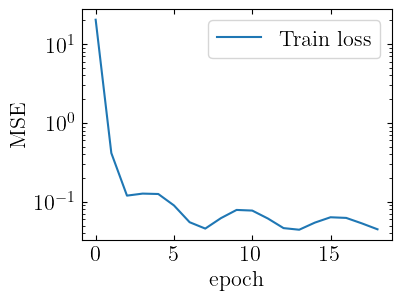

In [ ]:
print(history['d_loss'][-1])
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.semilogy(history["loss"], label="Train loss")
# ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend()

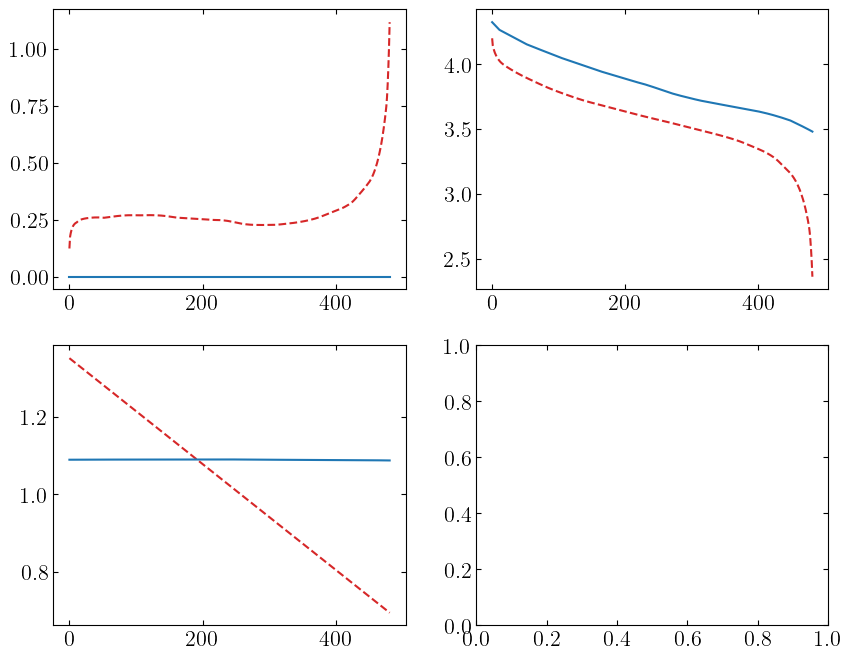

In [ ]:
def evaluate(model, x_test, y_test):
    model.eval()
    with torch.no_grad():
        I = x_test[0]
        u = x_test[1]
        Ue = x_test[2]

        R0_pred, F_pred = model(x_test)
        y_pred = torch.stack([ECM_box(Ue,I,R0_pred), Mech_box(u,F_pred)])

        test_loss = nn.MSELoss()(y_pred, y_test).item()
    #print(f"Test MSE: {test_loss:.3e}")
    return y_pred.detach().numpy(), R0_pred.detach().numpy(), F_pred.detach().numpy()   


traj_eval = 6
R0 = np.zeros(len(x_train[x_train[:,3] == traj_eval]))
F = np.zeros(len(x_train[x_train[:,3] == traj_eval]))
y_pred = np.zeros((len(x_train[x_train[:,3] == traj_eval]), 2))


for i in range(len(y_pred)):
    y_pred[i,:], R0[i],F[i] = evaluate(model, x_train[x_train[:,3] == traj_eval][i,:3], y_train[y_train[:,2] == traj_eval][i,:2])


f, ax = plt.subplots(2, 2, figsize=(10, 8))
#plt.plot(x_test[:,0].numpy()* R0.detach().numpy(), label='Predicted $R_0$')
ax[0,0].plot(x_train[x_train[:,3] == traj_eval][:,0].numpy()* R0, label=r'Predicted $R_0$',color = colors[0])
ax[0,0].plot(-data['eta'][data['trajectory'] == traj_eval].values, label=r'True $\eta$',color = colors[1],ls = '--')
ax[0,1].plot(data['V'][data['trajectory'] == traj_eval].values, label=r'True $V$', color = colors[1],ls = '--')
ax[0,1].plot(y_pred[:,0], label=r'Predicted $V$', color = colors[0])
ax[1,0].plot(data['F'][data['trajectory'] == traj_eval].values, label=r'True $F$', color = colors[1],ls = '--')
ax[1,0].plot(y_pred[:,1], label=r'Predicted $F$', color = colors[0])    
